## Module 1 Class activities
This notebook is a starting point for the exercises and activities that we'll do in class.

Before you attempt any of these activities, make sure to watch the Module 1 video lectures.

### Using the `requests` library to query an API
Here's the code that we saw in the video lecture that queries BART for real-time arrivals.

In [5]:
import json
import pandas as pd
import requests

APIkey = 'QB8J-5LTQ-9W9T-DWEI'  # the key posted on BART's website
station = 'CIVC'
requestString = 'http://api.bart.gov/api/etd.aspx?cmd=etd&orig={}&json=y&key={}'.format(station, APIkey)
r = requests.get(requestString) #this is explained in lecture 1a (requests.get())
d = json.loads(r.text) #this is explained in lecture 1a (jason.loads())      json.loads() will turn the JSON object into a dictionary
etd = d['root']['station'][0]['etd']
print('Trains from {} to {}'.format(station, etd[0]['destination']))
df = pd.DataFrame(etd[0]['estimate'])
df

Trains from CIVC to Antioch


,minutes,platform,direction,length,color,hexcolor,bikeflag,delay,cancelflag,dynamicflag
0,4,2,North,8,YELLOW,#ffff33,1,69,0,0
1,23,2,North,8,YELLOW,#ffff33,1,0,0,0
2,43,2,North,8,YELLOW,#ffff33,1,0,0,0


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Explore the different objects. What are <strong>r</strong>, <strong>d</strong>, and <strong>etd</strong>. What can you do with them?
</div>

Hint: Use `type()` to find out the type of an object (e.g. `type(r)`), and `?` to pull up the help screen (e.g. `r?`).

You can also tab autocomplete to discover an object's attributes and methods (e.g. `r.` and then `TAB`). 

In [2]:
# your code here
r.

SyntaxError: invalid syntax (511984038.py, line 2)

Now let's explore the other options and API commands that BART offers. 

The API documentation for the `etd` (real-time information) command is [here](https://api.bart.gov/docs/etd/etd.aspx). 

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Write a command to retrieve real-time departures for southbound trains at Civic Center station (code: CIVC). Hint: You'll need to add another <strong>&</strong> to <strong>requestString</strong>.
</div>

In [6]:
# suggested solution
station = 'CIVC'
requestString = 'http://api.bart.gov/api/etd.aspx?cmd=etd&orig={}&json=y&key={}&dir=s'.format(station, APIkey)
r_2 = requests.get(requestString)
d_2 = json.loads(r_2.text)
etd_2 = d_2['root']['station'][0]['etd'][0]['estimate']
pd.DataFrame(etd_2)

,minutes,platform,direction,length,color,hexcolor,bikeflag,delay,cancelflag,dynamicflag
0,2,1,South,6,GREEN,#339933,1,0,0,0
1,10,1,South,6,BLUE,#0099cc,1,0,0,0
2,22,1,South,6,GREEN,#339933,1,0,0,0


<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Use the <strong>elev</strong> command to obtain the elevator status at each station, and put it in a dataframe. Optional extension: pass the parameters as a dictionary to requests, as we saw in the video lecture.

See the API docs [here](https://api.bart.gov/docs/bsa/elev.aspx) for details of that command.

In [7]:
requestString = 'http://api.bart.gov/api/bsa.aspx?cmd=elev&json=y&key={}'.format(APIkey)
r = requests.get(requestString)
d = json.loads(r.text)
pd.DataFrame(d['root']['bsa'])

# note that there isn't a station-by-station response, so this is a less satisfying
# dataframe than before
# we could go further, but would need to extract the stations from the description colum

,@id,station,type,description,sms_text,posted,expires
0,04090232,BART,ELEVATOR,{'#cdata-section': 'There is 1 elevator out of...,{'#cdata-section': '1 elev out of svc: COLS: p...,,


### Accessing census data

Recall that we accessed census data using the Census Bureau API.

Here's the relevant code that we saw in the video lecture to get the 5-year ACS estimates for population (table `B01001_001E`).

In [8]:
import json
import requests
import pandas as pd

r = requests.get('https://api.census.gov/data/2023/acs/acs5?get=B01001_001E&for=county')
censusdata = r.json()
df = pd.DataFrame(censusdata[1:], columns=censusdata[0]) #0行目はcolumn名で、データは1行目から、という意味
df.head()

,B01001_001E,state,county
0,59285,01,001
1,239945,01,003
2,24757,01,005
3,22152,01,007
4,59292,01,009


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Retrieve population data at the census tract level for LA County, and put it in a pandas dataframe. (You can use the 5-year ACS if you like.)
</div>

Some examples are given [here](https://api.census.gov/data/2015/acs/acs5/examples.html). 

Note that you don't need the API key for a small number of queries, so you can delete `&key=YOUR_KEY_GOES_HERE` from the examples. 

The FIPS code for California is `06` and for Los Angeles County `037`.

In [9]:
# This is the example from the link below
# https://api.census.gov/data/2015/acs/acs5?get=NAME,B01001_001E&for=tract:020500&in=state:01%20county:001&key=YOUR_KEY_GOES_HERE
# here, we adapt it to get all tracts (*) in state 06 and county 037

r = requests.get('https://api.census.gov/data/2023/acs/acs5?get=NAME,B01001_001E&for=tract:*&in=state:06%20county:037')
censusdata = r.json() #.json() でrをPythonで扱えるようにする

#censusdata[1:]: データ部分（1行目を除いたリスト）、columns=censusdata[0]: 列名（1行目）をカラム名に指定
df = pd.DataFrame(censusdata[1:], columns=censusdata[0]) 
df.head()

,NAME,B01001_001E,state,county,tract
0,Census Tract 1011.10; Los Angeles County; Cali...,4152,06,037,101110
1,Census Tract 1011.22; Los Angeles County; Cali...,4198,06,037,101122
2,Census Tract 1012.20; Los Angeles County; Cali...,3434,06,037,101220
3,Census Tract 1012.21; Los Angeles County; Cali...,3931,06,037,101221
4,Census Tract 1012.22; Los Angeles County; Cali...,2572,06,037,101222


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Retrieve the census data for race/ethnicity for tracts in Los Angeles county, and put it in a pandas dataframe. 
</div>

Hints:
* The list of variables is [here](https://api.census.gov/data/2015/acs/acs5/variables.html).
* The data is crosstabulated by race and age and gender. If you just want race/ethnicity, then look at the `Estimate!!Total:` variables. For example, `B01001H_001E` gives the total number of non-Hispanic white people, without further disaggregating by gender and age. 
* Start with the simplest measure of race. For example, you could calculate the proportion of Black people or non-Hispanic white people in each census tract, by dividing the relevant variable by the total population (which you already retrieved above).
* You can request multiple variables at once - just separate them with commas. For example, `get=NAME,B01001_001E,B01001H_001E`. 
* `NAME` means that you are requesting the description of the geography - this is optional.


In [11]:
# let's calculate the % of residents who are non-Hispanic White
# looking at the list of variables, we need B01001_001E (total) and B01001H_001E (non-Hispanic white)

r = requests.get('https://api.census.gov/data/2015/acs/acs5?get=NAME,B01001_001E,B01001H_001E&for=tract:*&in=state:06%20county:037')
censusdata = r.json()
df = pd.DataFrame(censusdata[1:], columns=censusdata[0])

# as we saw in class, the data are strings
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2346 entries, 0 to 2345
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NAME          2346 non-null   object
 1   B01001_001E   2346 non-null   object
 2   B01001H_001E  2346 non-null   object
 3   state         2346 non-null   object
 4   county        2346 non-null   object
 5   tract         2346 non-null   object
dtypes: object(6)
memory usage: 110.1+ KB


In [12]:
# so to calculate the percentage, we first convert to a float.
# integer will not work here as it cannot hold NaN (missing data)

#df['pc_nonHispanicWhite'] で新しいcolumnを作っている
df['pc_nonHispanicWhite'] = df.B01001H_001E.astype(float) / df.B01001_001E.astype(float) * 100 
df.head()

,NAME,B01001_001E,B01001H_001E,state,county,tract,pc_nonHispanicWhite
0,"Census Tract 5301.02, Los Angeles County, Cali...",5308,957,06,037,530102,18.029390
1,"Census Tract 1046.10, Los Angeles County, Cali...",3385,41,06,037,104610,1.211226
2,"Census Tract 1065.10, Los Angeles County, Cali...",5151,966,06,037,106510,18.753640
3,"Census Tract 1066.41, Los Angeles County, Cali...",2145,1350,06,037,106641,62.937063
4,"Census Tract 1132.13, Los Angeles County, Cali...",4714,2118,06,037,113213,44.929996


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Can you write a function that retrieves population by race for all census tracts in a specified county? (Or a simplified measure of race, such as the proportion of Black people.) 
</div>

Hint: use the code you wrote, but replace the county FIPS code `037` with a variable. Your function can take a single argument, e.g. `countyFIPS`.

In [13]:
def get_nhWhite(countyFIPS):
    # same as above, except 037 is replaced by our countyFIPS variable
    r = requests.get('https://api.census.gov/data/2015/acs/acs5?get=NAME,B01001_001E,B01001H_001E&for=tract:*&in=state:06%20county:{}'.format(countyFIPS))
    censusdata = r.json()
    df = pd.DataFrame(censusdata[1:], columns=censusdata[0])
    df['pc_nonHispanicWhite'] = df.B01001H_001E.astype(float) / df.B01001_001E.astype(float) * 100 

    return df

# for Marin County
#最初に"def get_nhWhite(countyFIPS)"でget_nhWhite()という関数を定義している。そこに入れる変数countyFIPSを変えれば各countyの値が出る
census = get_nhWhite('041') 
census

,NAME,B01001_001E,B01001H_001E,state,county,tract,pc_nonHispanicWhite
0,"Census Tract 9901, Marin County, California",0,0,06,041,990100,NaN
1,"Census Tract 1022.02, Marin County, California",6515,4287,06,041,102202,65.801995
2,"Census Tract 1022.03, Marin County, California",5371,2645,06,041,102203,49.245950
3,"Census Tract 1090.01, Marin County, California",3951,2285,06,041,109001,57.833460
4,"Census Tract 1090.02, Marin County, California",4068,3700,06,041,109002,90.953786
5,"Census Tract 1122.01, Marin County, California",7330,275,06,041,112201,3.751705
6,"Census Tract 1122.02, Marin County, California",4660,822,06,041,112202,17.639485
7,"Census Tract 1192.01, Marin County, California",3406,2472,06,041,119201,72.577804
8,"Census Tract 1192.02, Marin County, California",3492,3057,06,041,119202,87.542955
9,"Census Tract 1302.01, Marin County, California",3643,3212,06,041,130201,88.169091


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Map your results!
</div>

You can use the `pygris` library to import the geographic boundary files.

Then you can join these boundaries to your census data. We'll cover joins in depth in a couple of weeks, but for now, you can adapt the code below.

In [1]:
import pygris
tracts = pygris.tracts(state='06',county='041', year=2022)

# if you get a 403 error, the Census Bureau might not be accepted requests
# a workaround: download the geographic boundary files from the website: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
# then, uncomment and run these lines


HTTPError: HTTP Error 403: Forbidden

In [15]:
import geopandas as gpd
# replace with the path and filename of what you just downloaded
tracts = gpd.read_file("/Users/Tomo/Desktop/UP213/Week1/tl_2024_06_tract.zip")  

# this sets some of the columns as the index, to make a join easier
#set_indexを使う事で、もともと0,1,2などとなっていた各行の識別情報（インデックス）を、set_index()のカッコ内の情報を使って識別できるようにするもの
#この識別情報（インデックス）は1つの列である必要はなく、ここのように複数の列情報を使うことが可能
#inplaceは、もともとのデータに上書きする、ということ
#そのうえで2行目でそれらの識別用の列の名前を変更している
tracts.set_index(['STATEFP','COUNTYFP','TRACTCE'], inplace=True)
tracts.index.names=['state','county','tract']

# suppose that your census data is in a dataframe called census
# the next line will add the geometry columns from tracts
#上で設定した識別情報（インデックス）を使って2つのデータセットを結合している
#「新しいデータセット名」 = 「加える列」.join(「結合先のデータセット名」.「識別に使うインデックス」)
census = tracts[['geometry']].join(census.set_index(['state','county','tract']))

Text(0.5, 1.0, 'Percent non-Hispanic white residents')

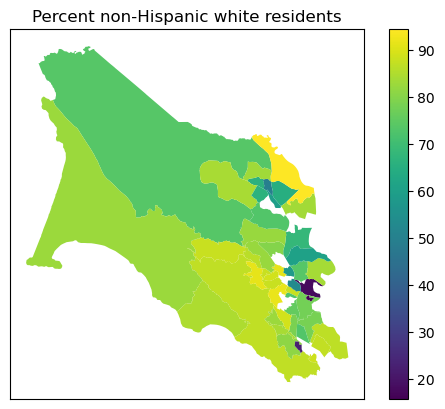

In [16]:
# your code here

import matplotlib.pyplot as plt

#pltを使ってマッピングするためのcode
fig, ax = plt.subplots() 
#データ名.plot（'変数名', ax = ax, legend=）という構造にする
census.plot('pc_nonHispanicWhite', ax = ax, legend=True)

# remove the tick labels
ax.set_xticks([])
ax.set_yticks([])

ax.set_title('Percent non-Hispanic white residents')

### Using Socrata

Here's the example that we saw in the lecture.

<Axes: >

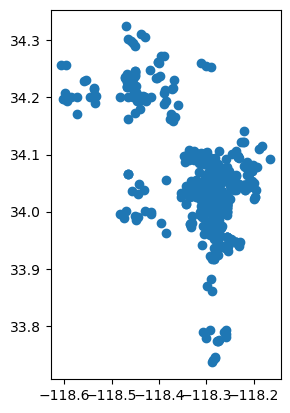

In [1]:
import geopandas as gpd
url = 'https://data.lacity.org/resource/mymu-zi3s.geojson'
gdf = gpd.read_file(url)
gdf.plot()

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Choose another dataset on Socrata, download it using the API, and map the results. 
</div>

The City of Los Angeles datasets are [here](https://data.lacity.org). Feel free to choose another city or county if you prefer.

Some possible datasets of planning-related interest:
* [DACA/DAPA workshops](https://data.lacity.org/Community-Economic-Development/Map2-DACA-DAPA-Workshops/icwt-9z3e) (seems a bit dated)
* [Solar PV permits](https://data.lacity.org/A-Prosperous-City/Solar-PV-Permits-in-LA/bdt7-w2xr)
* [Parks](https://data.lacity.org/Community-Economic-Development/Department-of-Recreation-and-Parks-Facility-and-Pa/ax8j-dhzm)

<Axes: >

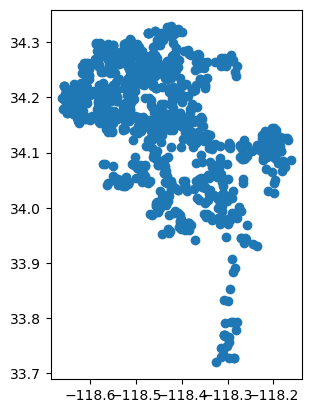

In [2]:
# your code here

# let's do solar
url = 'https://data.lacity.org/resource/bdt7-w2xr.geojson'
gdf = gpd.read_file(url)
gdf.plot()

Text(0.5, 1.0, 'Solar PV permits, City of Los Angeles')

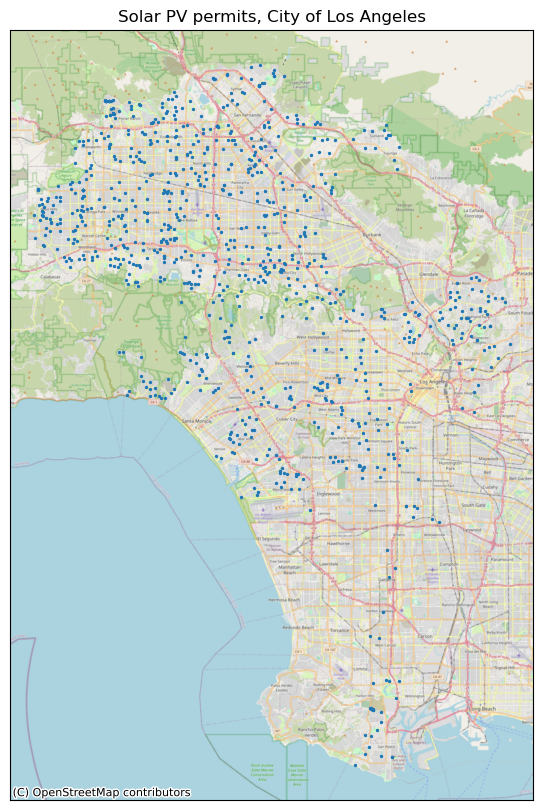

In [3]:
# clean it up a bit
import matplotlib.pyplot as plt
import contextily as ctx

# easier if we pre-create an axis object
fig, ax = plt.subplots(figsize=(10,10))

# project to 3857 to match the basemap
# use the markersize keyword to make the points smaller
gdf.to_crs('EPSG:3857').plot(ax=ax, markersize=2)

# add a basemap
# for more options, see https://contextily.readthedocs.io/en/latest/providers_deepdive.html
# I chose xyz.OpenStreetMap.Mapnik
ctx.add_basemap(ax=ax, zoom=12, source=ctx.providers.OpenStreetMap.Mapnik)

# drop the tick labels
ax.set_xticks([])
ax.set_yticks([])

# add a title
ax.set_title('Solar PV permits, City of Los Angeles')

In [4]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<div class="alert alert-block alert-info">
<h3>What you should have learned</h3>
<ul>
  <li>Gain confidence in experimenting with code - exploring different objects, writing functions, and so on</li>
  <li>Learn how to read API documentation and adapt the examples to create your own queries.</li>
  <li>Gain confidence in mapping the results. We'll practice this much more throughout the quarter.</li>
</ul>
</div>